# Top-10画像選出によるROP分類性能評価

## 概要

multicenter_studyのclinical_v3モデル（5タスク、全臨床融合）は全Good+Fair画像6,448枚で評価されている。
臨床現場では動画から高品質画像のみを選別してAI判定に使う運用が想定される。

bestimage_validationで開発した **C-rule3_thr0.80**（edge_cov≥0.80フィルタ + 3特徴量スコアリング）を
multicenter画像に適用し、患者ごとtop-10画像のみで評価した場合の分類性能を検証する。

## アルゴリズム

| Stage | 条件 | スコアリング |
|-------|------|-------------|
| Stage 1 | `disc_edge_coverage_ratio >= 0.80` | `0.4*retina_norm + 0.4*grad_norm + 0.2*mbss_norm` → 上位10枚 |
| Stage 2 (Fallback) | Stage1候補 < 10枚の場合 | `retina_ratio` 降順で残りを補完 |

## 評価タスク

- **Multiclass**: Zone (I/II/III), Stage (0-3), Plus (normal/preplus/plus)
- **Binary**: Aggressive ROP (AROP), Treatment
- **Derived**: RW-ROP = Plus(2) OR Stage(3) OR Zone(0)

In [16]:
import sys
import json
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, confusion_matrix, cohen_kappa_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm

# Japanese font support
try:
    matplotlib.rcParams['font.family'] = 'MS Gothic'
except Exception:
    pass

# ==================== Path Config ====================
BASE_DIR = Path(r"C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study")
PREDICTIONS_PATH = BASE_DIR / "outputs_clinical_v3" / "predictions.csv"
KUBOTA_EXCEL_PATH = Path(r"E:\Multicenter_ROP_study\Multicenter_images\Kubota_selection\selected_images_disc_retina.xlsx")
TOPLEVEL_EXCEL_PATH = Path(r"E:\Multicenter_ROP_study\Multicenter_images\selected_images_disc_retina.xlsx")
KUBOTA_IMAGE_DIR = Path(r"E:\Multicenter_ROP_study\Multicenter_images\Kubota_selection")
OUTPUT_DIR = BASE_DIR / "outputs_clinical_v3"

# Model paths (for Cell 3 feature recalculation)
MODELS_DIR = Path(r"C:\Users\ykita\ROP_AI_project\ROP_project\models")
YOLO_SEG_MODEL_PATH = MODELS_DIR / "yolo11n-seg_19movies.pt"

# ==================== Module imports ====================
sys.path.insert(0, str(BASE_DIR))
from quality_assessment import (
    compute_mbss_components, compute_disc_edge_coverage, compute_mbss_score
)
from select_best_images import minmax_norm

# ==================== Constants ====================
EDGE_COVERAGE_CUTOFF = 0.80
WEIGHT_RETINA = 0.4
WEIGHT_GRAD = 0.4
WEIGHT_MBSS = 0.2
TOP_K = 10
YOLO_INPUT_WIDTH = 640

print("=== Config ===")
print(f"Predictions: {PREDICTIONS_PATH}")
print(f"Kubota Excel: {KUBOTA_EXCEL_PATH}")
print(f"Top-level Excel: {TOPLEVEL_EXCEL_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"Top-K: {TOP_K}")
print(f"Edge coverage cutoff: {EDGE_COVERAGE_CUTOFF}")

=== Config ===
Predictions: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_clinical_v3\predictions.csv
Kubota Excel: E:\Multicenter_ROP_study\Multicenter_images\Kubota_selection\selected_images_disc_retina.xlsx
Top-level Excel: E:\Multicenter_ROP_study\Multicenter_images\selected_images_disc_retina.xlsx
Output: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_clinical_v3
Top-K: 10
Edge coverage cutoff: 0.8


In [17]:
# ==================== データ読み込み・結合 ====================

# 1. predictions.csv 読み込み
pred_df = pd.read_csv(PREDICTIONS_PATH)
pred_df['image_name'] = pred_df['image_path'].apply(
    lambda x: x.split('\\')[-1].split('/')[-1]
)
print(f"predictions.csv: {len(pred_df)} images, {pred_df['video_id'].nunique()} video_ids")

# 2. Kubota Excel 読み込み
kubota_df = pd.read_excel(KUBOTA_EXCEL_PATH)
print(f"Kubota Excel: {len(kubota_df)} rows, {kubota_df['image_id'].nunique()} video_ids")
print(f"Kubota columns: {kubota_df.columns.tolist()}")

# 品質特徴量カラム
feat_cols = ['retina_ratio', 'mbss_Grad_p90', 'mbss_score',
             'disc_detected', 'disc_edge_coverage_ratio']
available_feat_cols = [c for c in feat_cols if c in kubota_df.columns]
print(f"Available feature columns: {available_feat_cols}")

# Kubota Excel から image_name + 特徴量のみ抽出（重複除去）
kubota_features = kubota_df[['image_name'] + available_feat_cols].drop_duplicates(
    subset='image_name', keep='first'
)

# 3. Left merge on image_name
merged_df = pred_df.merge(kubota_features, on='image_name', how='left')

# 4. 結合結果サマリ
n_matched = merged_df['retina_ratio'].notna().sum()
n_missing = merged_df['retina_ratio'].isna().sum()
missing_vids = sorted(merged_df[merged_df['retina_ratio'].isna()]['video_id'].unique())

print(f"\n{'='*60}")
print(f"=== Merge結果 ===")
print(f"一致: {n_matched} images ({n_matched/len(merged_df)*100:.1f}%)")
print(f"未一致 (特徴量なし): {n_missing} images ({n_missing/len(merged_df)*100:.1f}%)")
print(f"未一致 video_ids: {len(missing_vids)}")
if 0 < len(missing_vids) <= 30:
    print(f"  {missing_vids}")

# video_id別の画像数分布
vid_counts = merged_df.groupby('video_id').size()
print(f"\n=== Video-ID別画像数 ===")
print(vid_counts.describe().to_string())

predictions.csv: 6448 images, 347 video_ids
Kubota Excel: 9218 rows, 358 video_ids
Kubota columns: ['image_id', 'rank', 'image_name', 'priority_group', 'retina_ratio', 'retina_area', 'disc_detected', 'disc_edge_coverage_ratio', 'disc_edge_covered', 'mbss_Grad_p90', 'mbss_score', 'S_mean', 'score']
Available feature columns: ['retina_ratio', 'mbss_Grad_p90', 'mbss_score', 'disc_detected', 'disc_edge_coverage_ratio']

=== Merge結果 ===
一致: 6182 images (95.9%)
未一致 (特徴量なし): 266 images (4.1%)
未一致 video_ids: 28
  ['0375_AMU', '0376_AMU', '0378_AMU', '0379_AMU', '0381_AMU', '0382_AMU', '0383_AMU', '0385_KCMC', '0386_KCMC', '0389_KCMC', '0390_KCMC', '0391_KCMC', '0393_KCMC', '0394_KCMC', '0395_KCMC', '0396_KCMC', '0397_KCMC', '0398_KCMC', '0399_KCMC', '0400_KCMC', '0401_KCMC', '0404_KCMC', '0405_KCMC', '0406_KCMC', '0407_KCMC', '0408_KCMC', '0409_KCMC', '0410_KCMC']

=== Video-ID別画像数 ===
count    347.000000
mean      18.582133
std        9.012260
min        1.000000
25%       11.000000
50%      

In [18]:
# ==================== 欠損特徴量の補完 ====================

missing_mask = merged_df['retina_ratio'].isna()
n_missing_before = missing_mask.sum()
print(f"特徴量欠損: {n_missing_before} images")

# ---------- Step 1: Top-level Excel から補完 ----------
if n_missing_before > 0 and TOPLEVEL_EXCEL_PATH.exists():
    print(f"\n--- Step 1: Top-level Excel から補完 ---")
    toplevel_df = pd.read_excel(TOPLEVEL_EXCEL_PATH)
    print(f"Top-level Excel: {len(toplevel_df)} rows")

    tl_feat_cols = [c for c in available_feat_cols if c in toplevel_df.columns]
    if 'image_name' in toplevel_df.columns and len(tl_feat_cols) > 0:
        toplevel_features = toplevel_df[['image_name'] + tl_feat_cols].drop_duplicates(
            subset='image_name', keep='first'
        ).set_index('image_name')

        # 欠損行のみ更新
        missing_names = merged_df.loc[missing_mask, 'image_name']
        for col in tl_feat_cols:
            fill_values = missing_names.map(toplevel_features[col])
            merged_df.loc[missing_mask, col] = fill_values.values

        # 再評価
        new_missing = merged_df['retina_ratio'].isna().sum()
        n_filled = n_missing_before - new_missing
        print(f"Top-level Excel で補完: {n_filled} images")
        print(f"残り欠損: {new_missing} images")
    else:
        print("Top-level Excel に必要なカラムがありません")
        new_missing = n_missing_before
elif n_missing_before > 0:
    print("Top-level Excel が見つかりません。Step 2 へ進みます。")
    new_missing = n_missing_before
else:
    new_missing = 0
    print("欠損なし。補完不要。")

# ---------- Step 2: YOLO-seg で再計算 ----------
still_missing_mask = merged_df['retina_ratio'].isna()
n_still_missing = still_missing_mask.sum()

if n_still_missing > 0:
    print(f"\n--- Step 2: YOLO-seg で特徴量を再計算 ({n_still_missing} images) ---")

    missing_images = merged_df.loc[still_missing_mask]
    missing_vid_ids = sorted(missing_images['video_id'].unique())
    print(f"対象 video_ids: {len(missing_vid_ids)}")

    # Check if images are accessible
    sample_path = Path(missing_images.iloc[0]['image_path'])
    if not sample_path.exists():
        print(f"WARNING: 画像ファイルにアクセスできません: {sample_path}")
        print(f"  E:ドライブが接続されていない可能性があります。")
        print(f"  -> {n_still_missing} images の特徴量は欠損のままです。")
        print(f"  -> Top-10選出時にこれらの画像は除外されます。")
    else:
        import torch
        from ultralytics import YOLO

        print(f"YOLO-seg モデル読み込み中: {YOLO_SEG_MODEL_PATH}")
        seg_model = YOLO(str(YOLO_SEG_MODEL_PATH))
        device = "cuda" if torch.cuda.is_available() else "cpu"
        if device == "cuda":
            seg_model.to('cuda')
        print(f"デバイス: {device}")

        for vid in tqdm(missing_vid_ids, desc="Video処理中"):
            vid_mask = (merged_df['video_id'] == vid) & merged_df['retina_ratio'].isna()
            vid_indices = merged_df[vid_mask].index.tolist()

            vid_results = []
            for idx in vid_indices:
                img_path = Path(merged_df.at[idx, 'image_path'])
                if not img_path.exists():
                    continue

                image = cv2.imread(str(img_path))
                if image is None:
                    continue

                h, w = image.shape[:2]
                cx, cy = w // 2, h // 2
                radius = (w + h) // 4

                # Circle mask
                circle_mask = np.zeros((h, w), dtype=np.uint8)
                cv2.circle(circle_mask, (cx, cy), radius, 255, -1)
                lens_area = int((circle_mask > 0).sum())

                masked = image.copy()
                masked[circle_mask == 0] = (114, 114, 114)

                # YOLO-seg inference
                ar = h / max(w, 1)
                yolo_h = int(YOLO_INPUT_WIDTH * ar)
                yolo_input = cv2.resize(masked, (YOLO_INPUT_WIDTH, yolo_h),
                                        interpolation=cv2.INTER_AREA)
                seg_results = seg_model(yolo_input, verbose=False, retina_masks=True)

                retina_area = 0
                disc_detected = False
                retina_mask_crop = None
                disc_mask_crop = None

                if seg_results and seg_results[0].masks is not None:
                    r0 = seg_results[0]
                    masks_data = r0.masks.data.cpu().numpy()
                    classes = r0.boxes.cls.cpu().numpy().astype(int)
                    for mask_data, cls_id in zip(masks_data, classes):
                        mask_resized = cv2.resize(mask_data, (w, h),
                                                  interpolation=cv2.INTER_LINEAR)
                        mask_bin = (mask_resized > 0.5) & (circle_mask > 0)
                        if cls_id == 0:  # Retina
                            retina_area = int(mask_bin.sum())
                            retina_mask_crop = mask_bin.astype(np.uint8) * 255
                        elif cls_id == 1:  # Disc
                            disc_detected = True
                            disc_mask_crop = mask_bin.astype(np.uint8) * 255

                rr = (retina_area / lens_area * 100.0) if lens_area > 0 else 0.0

                # MBSS components
                if retina_mask_crop is not None:
                    mb = compute_mbss_components(image, mask01=retina_mask_crop)
                else:
                    mb = {"L_multi": None, "HF_ratio": None,
                          "Spec_centroid": None, "Grad_p90": None, "S_mean": None}

                # Disc edge coverage
                dec_ratio = None
                if disc_mask_crop is not None and retina_mask_crop is not None:
                    _, dec_ratio = compute_disc_edge_coverage(disc_mask_crop, retina_mask_crop)

                vid_results.append({
                    'idx': idx,
                    'retina_ratio': round(float(rr), 2),
                    'disc_detected': bool(disc_detected),
                    'disc_edge_coverage_ratio': dec_ratio,
                    'mbss_Grad_p90': mb['Grad_p90'],
                    'mbss_L_multi': mb['L_multi'],
                    'mbss_HF_ratio': mb['HF_ratio'],
                    'mbss_Spec_centroid': mb['Spec_centroid'],
                })

            if not vid_results:
                continue

            # Compute mbss_score (z-score within video)
            mb_keys = ['L_multi', 'HF_ratio', 'Spec_centroid', 'Grad_p90']
            stats = {}
            for k in mb_keys:
                vals = [r[f'mbss_{k}'] for r in vid_results if r[f'mbss_{k}'] is not None]
                if len(vals) > 0 and np.std(vals) > 0:
                    stats[k] = {"mean": float(np.mean(vals)), "std": float(np.std(vals))}
                elif len(vals) > 0:
                    stats[k] = {"mean": float(np.mean(vals)), "std": 1.0}

            for r in vid_results:
                idx = r['idx']
                merged_df.at[idx, 'retina_ratio'] = r['retina_ratio']
                merged_df.at[idx, 'disc_detected'] = r['disc_detected']
                merged_df.at[idx, 'disc_edge_coverage_ratio'] = r['disc_edge_coverage_ratio']
                merged_df.at[idx, 'mbss_Grad_p90'] = r['mbss_Grad_p90']

                # mbss_score from z-score
                comps = {k: r[f'mbss_{k}'] for k in mb_keys}
                if len(stats) == len(mb_keys):
                    merged_df.at[idx, 'mbss_score'] = compute_mbss_score(comps, stats)
                else:
                    merged_df.at[idx, 'mbss_score'] = None

        # Cleanup
        del seg_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print("YOLO-seg 再計算完了")

# ==================== 最終確認 ====================
final_missing = merged_df['retina_ratio'].isna().sum()
final_with_features = len(merged_df) - final_missing
print(f"\n{'='*60}")
print(f"=== 最終結果 ===")
print(f"特徴量あり: {final_with_features} / {len(merged_df)} images")
print(f"特徴量なし: {final_missing} images")
if final_missing > 0:
    missing_final_vids = sorted(merged_df[merged_df['retina_ratio'].isna()]['video_id'].unique())
    print(f"  対象 video_ids ({len(missing_final_vids)}): {missing_final_vids[:10]}...")
print(f"Total video_ids: {merged_df['video_id'].nunique()}")
print(f"\ndisc_detected=True: {(merged_df['disc_detected'] == True).sum()}")
print(f"disc_edge_coverage>=0.80: {(merged_df['disc_edge_coverage_ratio'] >= 0.80).sum()}")

特徴量欠損: 266 images

--- Step 1: Top-level Excel から補完 ---
Top-level Excel: 984 rows
Top-level Excel で補完: 266 images
残り欠損: 0 images

=== 最終結果 ===
特徴量あり: 6448 / 6448 images
特徴量なし: 0 images
Total video_ids: 347

disc_detected=True: 6448
disc_edge_coverage>=0.80: 6092


In [19]:
# ==================== C-rule3_thr0.80 による Top-10 選出 ====================

def select_top_k_per_video(df, top_k=10, edge_cov_cutoff=0.80):
    """
    video_idごとにC-rule3_thr0.80でtop-k画像を選出

    Stage 1: disc_detected=True & disc_edge_coverage_ratio >= cutoff
             → score = 0.4*retina_norm + 0.4*grad_norm + 0.2*mbss_norm 降順
    Stage 2 (Fallback): 残りを retina_ratio 降順で補完
    """
    all_selected = []
    summary = {
        'total_videos': 0, 'stage1_only': 0, 'needed_fallback': 0,
        'insufficient': 0, 'no_features': 0
    }

    for vid, group in df.groupby('video_id'):
        summary['total_videos'] += 1

        # 特徴量がある画像のみ（retina_ratio > 0）
        valid = group[group['retina_ratio'].notna() & (group['retina_ratio'] > 0)].copy()
        if len(valid) == 0:
            summary['no_features'] += 1
            continue

        # Stage 1: edge_cov >= cutoff
        stage1 = valid[
            (valid['disc_detected'] == True) &
            valid['disc_edge_coverage_ratio'].notna() &
            (valid['disc_edge_coverage_ratio'] >= edge_cov_cutoff)
        ].copy()

        if len(stage1) > 0:
            # MinMax normalization (per-video, Stage1 candidates only)
            stage1['retina_norm'] = minmax_norm(stage1['retina_ratio'].fillna(0))
            stage1['grad_norm'] = minmax_norm(stage1['mbss_Grad_p90'].fillna(0))
            stage1['mbss_norm'] = minmax_norm(stage1['mbss_score'].fillna(0))
            stage1['quality_score'] = (
                WEIGHT_RETINA * stage1['retina_norm'] +
                WEIGHT_GRAD * stage1['grad_norm'] +
                WEIGHT_MBSS * stage1['mbss_norm']
            )
            stage1 = stage1.sort_values('quality_score', ascending=False)
            selected = stage1.head(top_k).copy()
            selected['selection_stage'] = 'Stage1_edge_cov>=0.80'
        else:
            selected = pd.DataFrame()

        # Stage 2: fallback (retina_ratio降順)
        n_remaining = top_k - len(selected)
        if n_remaining > 0:
            used_idx = selected.index if len(selected) > 0 else pd.Index([])
            remaining = valid[~valid.index.isin(used_idx)].copy()
            if len(remaining) > 0:
                remaining = remaining.sort_values('retina_ratio', ascending=False)
                fallback = remaining.head(n_remaining).copy()
                fallback['selection_stage'] = 'Stage2_fallback'
                selected = pd.concat([selected, fallback])

            if len(selected) < top_k:
                summary['insufficient'] += 1
            elif n_remaining > 0:
                summary['needed_fallback'] += 1
            else:
                summary['stage1_only'] += 1
        else:
            summary['stage1_only'] += 1

        if len(selected) > 0:
            selected['rank'] = range(1, len(selected) + 1)
            all_selected.append(selected)

    top_df = pd.concat(all_selected, ignore_index=True) if all_selected else pd.DataFrame()
    return top_df, summary


# 実行
top10_df, selection_summary = select_top_k_per_video(
    merged_df, top_k=TOP_K, edge_cov_cutoff=EDGE_COVERAGE_CUTOFF
)

# サマリ表示
print(f"{'='*60}")
print(f"=== Top-{TOP_K} 選出結果 ===")
print(f"全画像: {len(merged_df)}")
print(f"Top-{TOP_K}画像: {len(top10_df)}")
n_top_vids = top10_df['video_id'].nunique() if len(top10_df) > 0 else 0
print(f"対象video_ids: {n_top_vids} / {selection_summary['total_videos']}")
print(f"  Stage1のみで十分: {selection_summary['stage1_only']}")
print(f"  Stage2補完あり: {selection_summary['needed_fallback']}")
print(f"  画像不足 (<{TOP_K}): {selection_summary['insufficient']}")
print(f"  特徴量なし: {selection_summary['no_features']}")

# Stage内訳
if len(top10_df) > 0:
    stage_counts = top10_df['selection_stage'].value_counts()
    print(f"\n=== Selection Stage 内訳 ===")
    for stage, count in stage_counts.items():
        print(f"  {stage}: {count} ({count/len(top10_df)*100:.1f}%)")

    # video別の選出数分布
    vid_top_counts = top10_df.groupby('video_id').size()
    print(f"\n=== Video別選出数 ===")
    print(f"  平均: {vid_top_counts.mean():.1f}")
    print(f"  最小: {vid_top_counts.min()}")
    print(f"  最大: {vid_top_counts.max()}")
    n_under = (vid_top_counts < TOP_K).sum()
    print(f"  <{TOP_K}: {n_under} videos")

=== Top-10 選出結果 ===
全画像: 6448
Top-10画像: 3089
対象video_ids: 347 / 347
  Stage1のみで十分: 262
  Stage2補完あり: 11
  画像不足 (<10): 74
  特徴量なし: 0

=== Selection Stage 内訳 ===
  Stage1_edge_cov>=0.80: 2975 (96.3%)
  Stage2_fallback: 114 (3.7%)

=== Video別選出数 ===
  平均: 8.9
  最小: 1
  最大: 10
  <10: 74 videos


In [20]:
# ==================== 評価関数の定義 ====================

def compute_multiclass_metrics(y_true, y_pred, class_names=None):
    """Zone/Stage/Plus用: accuracy, kappa, f1_macro, per-class sensitivity/PPV"""
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)

    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    per_class = {}
    for i, label in enumerate(labels):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        name = class_names[i] if class_names and i < len(class_names) else str(label)
        per_class[name] = {'sensitivity': sens, 'ppv': ppv}

    return {
        'accuracy': acc,
        'kappa': kappa,
        'f1_macro': f1_mac,
        'per_class': per_class,
    }


def compute_binary_metrics(y_true, y_pred, y_prob=None):
    """AROP/Treatment/RW-ROP用: accuracy, sens, spec, PPV, NPV, F1, AUC"""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    result = {
        'accuracy': accuracy_score(y_true, y_pred),
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'ppv': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'npv': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
    }

    if y_prob is not None and len(set(y_true)) > 1:
        result['auc'] = roc_auc_score(y_true, y_prob)
    else:
        result['auc'] = None

    return result


def compute_rw_rop(df):
    """RW-ROP導出: hard prediction (OR) + soft probability"""
    rw_true = (
        (df['plus_label'] == 2) |
        (df['stage_label'] == 3) |
        (df['zone_label'] == 0)
    ).astype(int)
    rw_pred = (
        (df['plus_pred'] == 2) |
        (df['stage_pred'] == 3) |
        (df['zone_pred'] == 0)
    ).astype(int)
    rw_prob = 1 - (
        (1 - df['plus_prob_2']) *
        (1 - df['stage_prob_3']) *
        (1 - df['zone_prob_0'])
    )
    return rw_true, rw_pred, rw_prob


def find_optimal_thresholds(y_true, y_prob, target_sensitivity=0.95):
    """閾値最適化: Sensitivity>=target, Youden's J"""
    if len(set(y_true)) < 2:
        return None

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)

    # Sensitivity >= target
    valid_idx = np.where(tpr >= target_sensitivity)[0]
    if len(valid_idx) > 0:
        best_idx = valid_idx[np.argmin(fpr[valid_idx])]
        thresh_sens = float(thresholds[best_idx])
    else:
        thresh_sens = float(thresholds[0])

    # Youden's J
    youden_j = tpr - fpr
    youden_idx = np.argmax(youden_j)
    thresh_youden = float(thresholds[youden_idx])

    return {
        'auc': auc_val,
        'sens_95': {'threshold': thresh_sens},
        'youden': {'threshold': thresh_youden},
    }


def evaluate_at_threshold(y_true, y_prob, threshold):
    """指定閾値での評価"""
    y_pred = (y_prob >= threshold).astype(int)
    return compute_binary_metrics(y_true, y_pred, y_prob)


def evaluate_all_tasks(df):
    """全タスク一括評価 -> dict of metrics"""
    results = {}

    # Zone (0=I, 1=II, 2=III)
    results['zone'] = compute_multiclass_metrics(
        df['zone_label'].values, df['zone_pred'].values,
        class_names=['Zone I', 'Zone II', 'Zone III']
    )

    # Stage (0-3)
    results['stage'] = compute_multiclass_metrics(
        df['stage_label'].values, df['stage_pred'].values,
        class_names=['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3']
    )

    # Plus (0=normal, 1=preplus, 2=plus)
    results['plus'] = compute_multiclass_metrics(
        df['plus_label'].values, df['plus_pred'].values,
        class_names=['Normal', 'Pre-plus', 'Plus']
    )

    # Aggressive ROP (binary)
    results['aggressive_rop'] = compute_binary_metrics(
        df['aggressive_rop_label'].values,
        df['aggressive_rop_pred'].values,
        df['aggressive_rop_prob_1'].values
    )

    # Treatment (binary)
    results['treatment'] = compute_binary_metrics(
        df['treatment_label'].values,
        df['treatment_pred'].values,
        df['treatment_prob_1'].values
    )

    # RW-ROP (derived)
    rw_true, rw_pred, rw_prob = compute_rw_rop(df)
    results['rw_rop'] = compute_binary_metrics(
        rw_true.values, rw_pred.values, rw_prob.values
    )

    return results


print("評価関数を定義しました")

評価関数を定義しました


In [21]:
# ==================== 全画像評価（ベースライン） ====================

print(f"=== 全画像評価 ({len(merged_df)} images, {merged_df['video_id'].nunique()} videos) ===\n")

baseline_results = evaluate_all_tasks(merged_df)

# Display
for task, metrics in baseline_results.items():
    print(f"\n--- {task} ---")
    for k, v in metrics.items():
        if k == 'per_class':
            for cls, cls_m in v.items():
                print(f"  {cls}: sens={cls_m['sensitivity']:.4f}, ppv={cls_m['ppv']:.4f}")
        elif v is not None:
            print(f"  {k}: {v:.4f}")

# Threshold optimization (baseline)
rw_true_all, _, rw_prob_all = compute_rw_rop(merged_df)
treat_true_all = merged_df['treatment_label']
treat_prob_all = merged_df['treatment_prob_1']

baseline_thresholds = {
    'treatment': find_optimal_thresholds(treat_true_all, treat_prob_all),
    'rw_rop': find_optimal_thresholds(rw_true_all, rw_prob_all),
}

print(f"\n{'='*60}")
print(f"=== Threshold Optimization (Baseline) ===")
for task_name in ['treatment', 'rw_rop']:
    y_t = treat_true_all if task_name == 'treatment' else rw_true_all
    y_p = treat_prob_all if task_name == 'treatment' else rw_prob_all
    opt = baseline_thresholds[task_name]
    if opt is None:
        continue
    print(f"\n  {task_name} (AUC={opt['auc']:.4f}):")
    for strat_name, strat_label in [('default_0.5', 0.5), ('sens_95', None), ('youden', None)]:
        if strat_name == 'default_0.5':
            thr = 0.5
        else:
            thr = opt[strat_name]['threshold']
        m = evaluate_at_threshold(y_t, y_p, thr)
        print(f"    {strat_name} (thr={thr:.4f}): "
              f"sens={m['sensitivity']:.4f}, spec={m['specificity']:.4f}, "
              f"ppv={m['ppv']:.4f}, npv={m['npv']:.4f}, f1={m['f1']:.4f}")

=== 全画像評価 (6448 images, 347 videos) ===


--- zone ---
  accuracy: 0.7323
  kappa: 0.6660
  f1_macro: 0.7132
  Zone I: sens=0.8173, ppv=0.5563
  Zone II: sens=0.6685, ppv=0.8776
  Zone III: sens=0.8417, ppv=0.6269

--- stage ---
  accuracy: 0.7298
  kappa: 0.7613
  f1_macro: 0.5780
  Stage 0: sens=0.0000, ppv=0.0000
  Stage 1: sens=0.7266, ppv=0.8761
  Stage 2: sens=0.7581, ppv=0.5860
  Stage 3: sens=0.6414, ppv=0.7205
  3: sens=0.8381, ppv=0.6888

--- plus ---
  accuracy: 0.8826
  kappa: 0.7502
  f1_macro: 0.5440
  Normal: sens=0.0000, ppv=0.0000
  Pre-plus: sens=0.9206, ppv=0.9831
  Plus: sens=0.7199, ppv=0.4787
  2: sens=0.6838, ppv=0.6200

--- aggressive_rop ---
  accuracy: 0.7779
  sensitivity: 0.8596
  specificity: 0.7749
  ppv: 0.1228
  npv: 0.9934
  f1: 0.2149
  kappa: 0.1631
  auc: 0.9164

--- treatment ---
  accuracy: 0.9491
  sensitivity: 0.9171
  specificity: 0.9526
  ppv: 0.6757
  npv: 0.9907
  f1: 0.7781
  kappa: 0.7501
  auc: 0.9780

--- rw_rop ---
  accuracy: 0.8986
  s

In [22]:
# ==================== Top-10 画像評価 ====================

print(f"=== Top-{TOP_K} 画像評価 ({len(top10_df)} images, {top10_df['video_id'].nunique()} videos) ===\n")

top10_results = evaluate_all_tasks(top10_df)

# Display
for task, metrics in top10_results.items():
    print(f"\n--- {task} ---")
    for k, v in metrics.items():
        if k == 'per_class':
            for cls, cls_m in v.items():
                print(f"  {cls}: sens={cls_m['sensitivity']:.4f}, ppv={cls_m['ppv']:.4f}")
        elif v is not None:
            print(f"  {k}: {v:.4f}")

# Threshold optimization (Top-10)
rw_true_top, _, rw_prob_top = compute_rw_rop(top10_df)
treat_true_top = top10_df['treatment_label']
treat_prob_top = top10_df['treatment_prob_1']

top10_thresholds = {
    'treatment': find_optimal_thresholds(treat_true_top, treat_prob_top),
    'rw_rop': find_optimal_thresholds(rw_true_top, rw_prob_top),
}

print(f"\n{'='*60}")
print(f"=== Threshold Optimization (Top-{TOP_K}) ===")
for task_name in ['treatment', 'rw_rop']:
    y_t = treat_true_top if task_name == 'treatment' else rw_true_top
    y_p = treat_prob_top if task_name == 'treatment' else rw_prob_top
    opt = top10_thresholds[task_name]
    if opt is None:
        continue
    print(f"\n  {task_name} (AUC={opt['auc']:.4f}):")
    for strat_name in ['default_0.5', 'sens_95', 'youden']:
        if strat_name == 'default_0.5':
            thr = 0.5
        else:
            thr = opt[strat_name]['threshold']
        m = evaluate_at_threshold(y_t, y_p, thr)
        print(f"    {strat_name} (thr={thr:.4f}): "
              f"sens={m['sensitivity']:.4f}, spec={m['specificity']:.4f}, "
              f"ppv={m['ppv']:.4f}, npv={m['npv']:.4f}, f1={m['f1']:.4f}")

=== Top-10 画像評価 (3089 images, 347 videos) ===


--- zone ---
  accuracy: 0.7339
  kappa: 0.6613
  f1_macro: 0.7110
  Zone I: sens=0.7890, ppv=0.5603
  Zone II: sens=0.6838, ppv=0.8710
  Zone III: sens=0.8296, ppv=0.6228

--- stage ---
  accuracy: 0.7193
  kappa: 0.7669
  f1_macro: 0.5668
  Stage 0: sens=0.0000, ppv=0.0000
  Stage 1: sens=0.7129, ppv=0.8923
  Stage 2: sens=0.7864, ppv=0.5631
  Stage 3: sens=0.6080, ppv=0.6830
  3: sens=0.7913, ppv=0.6984

--- plus ---
  accuracy: 0.8792
  kappa: 0.7332
  f1_macro: 0.5268
  Normal: sens=0.0000, ppv=0.0000
  Pre-plus: sens=0.9227, ppv=0.9838
  Plus: sens=0.6916, ppv=0.5011
  2: sens=0.6453, ppv=0.5163

--- aggressive_rop ---
  accuracy: 0.7731
  sensitivity: 0.8889
  specificity: 0.7696
  ppv: 0.1038
  npv: 0.9957
  f1: 0.1858
  kappa: 0.1410
  auc: 0.9357

--- treatment ---
  accuracy: 0.9453
  sensitivity: 0.9254
  specificity: 0.9474
  ppv: 0.6500
  npv: 0.9918
  f1: 0.7636
  kappa: 0.7338
  auc: 0.9798

--- rw_rop ---
  accuracy: 0.88

=== 全画像 (6448) vs Top-10 (3089) 比較 ===

          Task      Metric All Images Top-10   Delta
          zone    accuracy     0.7323 0.7339 +0.0016
          zone       kappa     0.6660 0.6613 -0.0047
          zone    f1_macro     0.7132 0.7110 -0.0022
         stage    accuracy     0.7298 0.7193 -0.0105
         stage       kappa     0.7613 0.7669 +0.0055
         stage    f1_macro     0.5780 0.5668 -0.0112
          plus    accuracy     0.8826 0.8792 -0.0034
          plus       kappa     0.7502 0.7332 -0.0170
          plus    f1_macro     0.5440 0.5268 -0.0173
aggressive_rop    accuracy     0.7779 0.7731 -0.0048
aggressive_rop sensitivity     0.8596 0.8889 +0.0292
aggressive_rop specificity     0.7749 0.7696 -0.0053
aggressive_rop         ppv     0.1228 0.1038 -0.0190
aggressive_rop         npv     0.9934 0.9957 +0.0023
aggressive_rop          f1     0.2149 0.1858 -0.0291
aggressive_rop         auc     0.9164 0.9357 +0.0194
     treatment    accuracy     0.9491 0.9453 -0.0038
     t

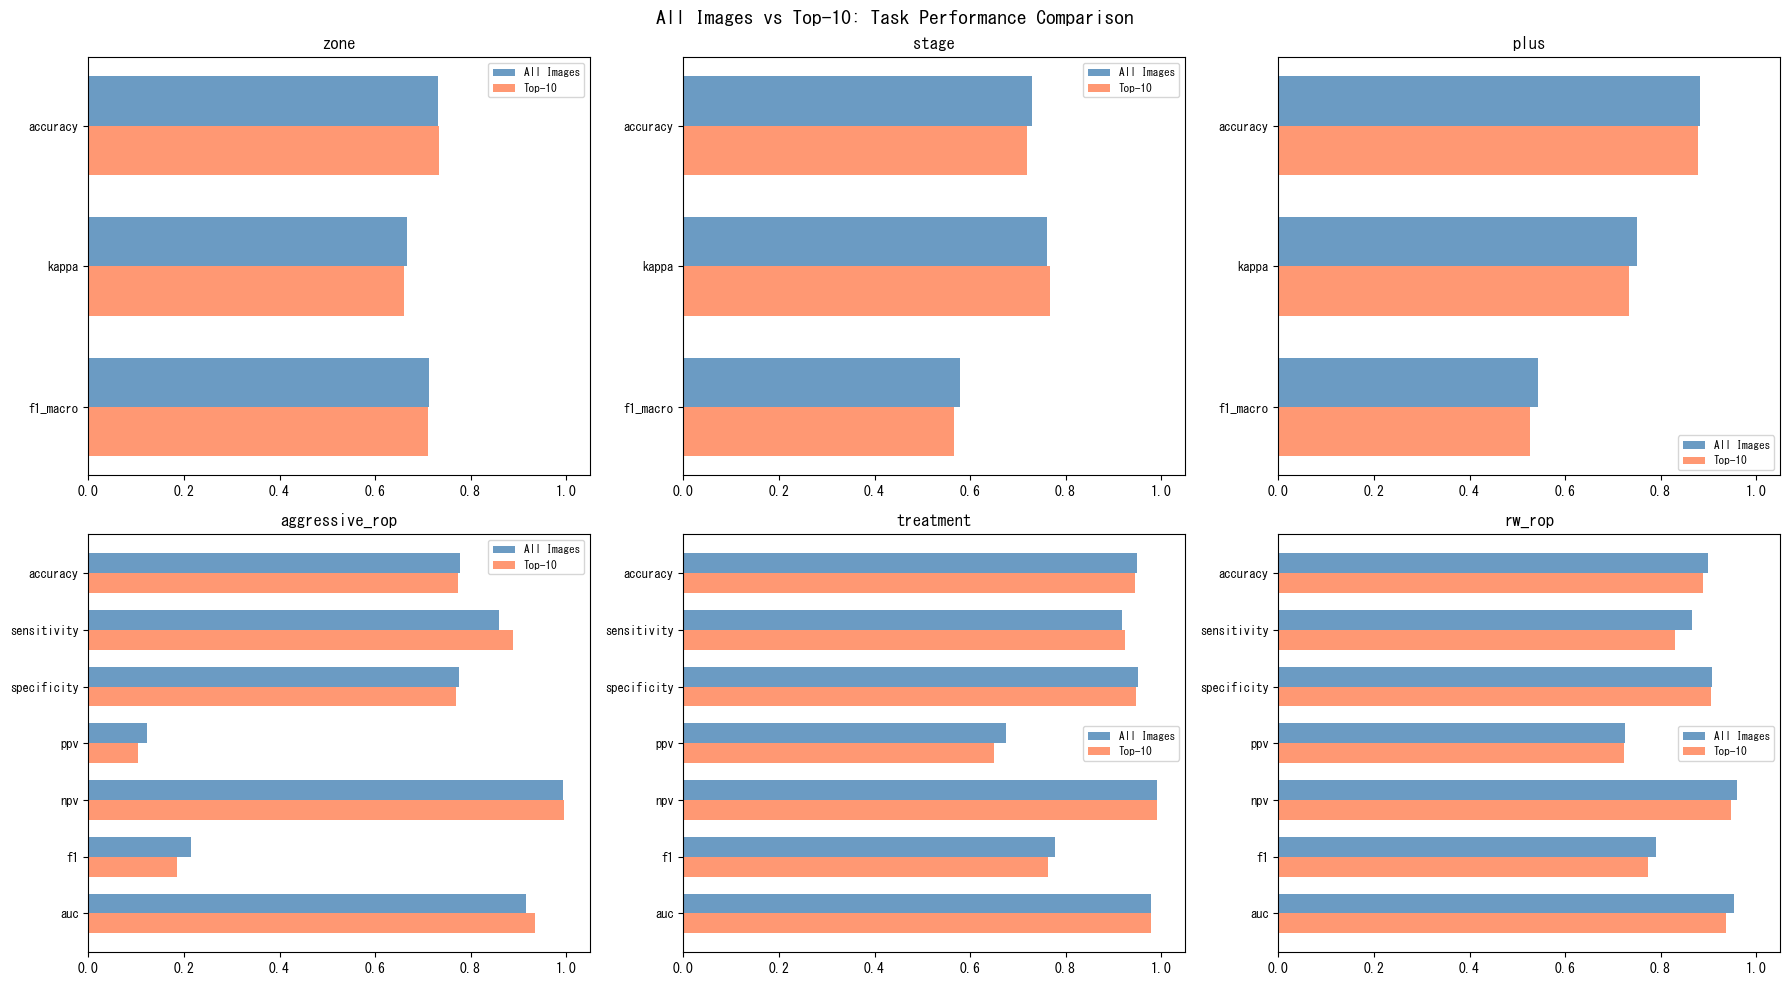

Chart saved: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_clinical_v3\top10_comparison_chart.png


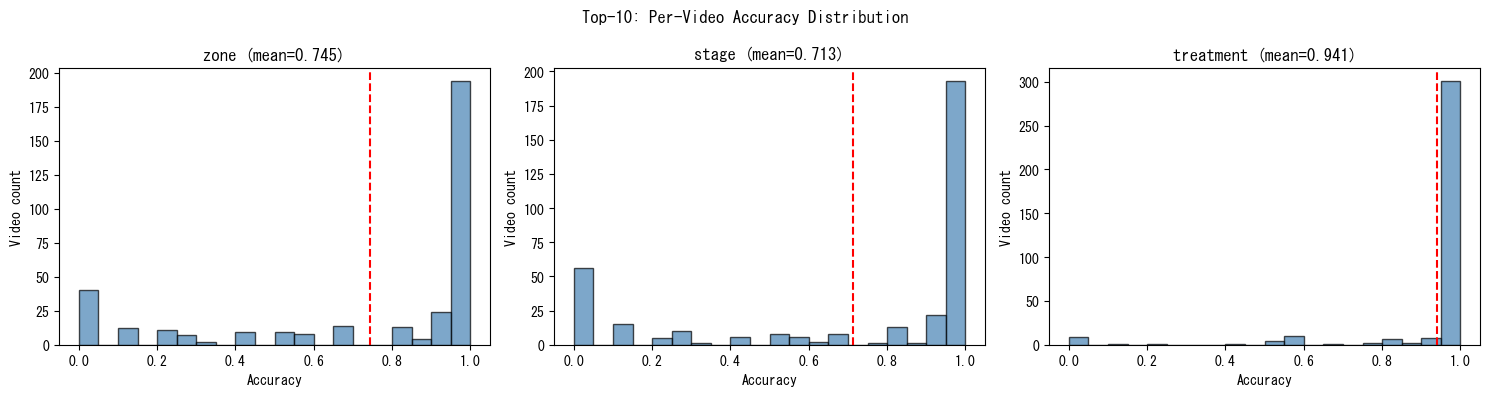

Histogram saved: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_clinical_v3\top10_per_video_accuracy.png


In [23]:
# ==================== 比較テーブル・可視化 ====================

# --- 1. Before/After テーブル ---
comparison_rows = []

# Multiclass tasks
for task in ['zone', 'stage', 'plus']:
    for metric in ['accuracy', 'kappa', 'f1_macro']:
        base_val = baseline_results[task][metric]
        top_val = top10_results[task][metric]
        delta = top_val - base_val
        comparison_rows.append({
            'Task': task, 'Metric': metric,
            'All Images': base_val,
            f'Top-{TOP_K}': top_val,
            'Delta': delta,
        })

# Binary tasks
for task in ['aggressive_rop', 'treatment', 'rw_rop']:
    for metric in ['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'f1', 'auc']:
        base_val = baseline_results[task].get(metric)
        top_val = top10_results[task].get(metric)
        if base_val is not None and top_val is not None:
            delta = top_val - base_val
            comparison_rows.append({
                'Task': task, 'Metric': metric,
                'All Images': base_val,
                f'Top-{TOP_K}': top_val,
                'Delta': delta,
            })

comp_df = pd.DataFrame(comparison_rows)

# Format for display
display_df = comp_df.copy()
display_df['All Images'] = display_df['All Images'].map(lambda x: f"{x:.4f}")
display_df[f'Top-{TOP_K}'] = display_df[f'Top-{TOP_K}'].map(lambda x: f"{x:.4f}")
display_df['Delta'] = display_df['Delta'].map(lambda x: f"{x:+.4f}")

print(f"=== 全画像 ({len(merged_df)}) vs Top-{TOP_K} ({len(top10_df)}) 比較 ===\n")
print(display_df.to_string(index=False))

# --- 2. 横棒グラフ比較 ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'All Images vs Top-{TOP_K}: Task Performance Comparison', fontsize=14)

tasks_to_plot = ['zone', 'stage', 'plus', 'aggressive_rop', 'treatment', 'rw_rop']
for i, task in enumerate(tasks_to_plot):
    ax = axes[i // 3][i % 3]
    task_rows = comp_df[comp_df['Task'] == task]
    metrics_list = task_rows['Metric'].tolist()
    base_vals = task_rows['All Images'].tolist()
    top_vals = task_rows[f'Top-{TOP_K}'].tolist()

    x = np.arange(len(metrics_list))
    width = 0.35
    ax.barh(x - width/2, base_vals, width, label='All Images', color='steelblue', alpha=0.8)
    ax.barh(x + width/2, top_vals, width, label=f'Top-{TOP_K}', color='coral', alpha=0.8)

    ax.set_yticks(x)
    ax.set_yticklabels(metrics_list, fontsize=9)
    ax.set_xlim(0, 1.05)
    ax.set_title(task)
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
chart_path = OUTPUT_DIR / 'top10_comparison_chart.png'
plt.savefig(str(chart_path), dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved: {chart_path}")

# --- 3. Video-ID別正解率ヒストグラム ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Top-{TOP_K}: Per-Video Accuracy Distribution', fontsize=12)

for i, task in enumerate(['zone', 'stage', 'treatment']):
    ax = axes[i]
    label_col = f'{task}_label'
    pred_col = f'{task}_pred'

    vid_accs = []
    for vid, group in top10_df.groupby('video_id'):
        if len(group) > 0:
            correct = (group[label_col] == group[pred_col]).sum()
            vid_accs.append(correct / len(group))

    ax.hist(vid_accs, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'{task} (mean={np.mean(vid_accs):.3f})')
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Video count')
    ax.axvline(np.mean(vid_accs), color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
hist_path = OUTPUT_DIR / 'top10_per_video_accuracy.png'
plt.savefig(str(hist_path), dpi=150, bbox_inches='tight')
plt.show()
print(f"Histogram saved: {hist_path}")

In [24]:
# ==================== 結果保存 ====================

def metrics_to_serializable(results):
    """Convert metrics dict to JSON-serializable format"""
    out = {}
    for task, metrics in results.items():
        out[task] = {}
        for k, v in metrics.items():
            if k == 'per_class':
                out[task][k] = {
                    cls: {mk: round(mv, 4) for mk, mv in m.items()}
                    for cls, m in v.items()
                }
            elif v is not None:
                out[task][k] = round(float(v), 4)
    return out


def thresholds_to_serializable(thresholds_dict, y_true_dict, y_prob_dict):
    """Convert threshold results to JSON-serializable format"""
    out = {}
    for task_name, opt in thresholds_dict.items():
        if opt is None:
            continue
        y_t = y_true_dict[task_name]
        y_p = y_prob_dict[task_name]
        out[task_name] = {'auc': round(opt['auc'], 4)}
        for strat in ['default_0.5', 'sens_95', 'youden']:
            thr = 0.5 if strat == 'default_0.5' else opt[strat]['threshold']
            m = evaluate_at_threshold(y_t, y_p, thr)
            out[task_name][strat] = {
                'threshold': round(thr, 4),
                **{k: round(v, 4) for k, v in m.items() if v is not None}
            }
    return out


# Prepare threshold data
rw_true_all, _, rw_prob_all = compute_rw_rop(merged_df)
rw_true_top, _, rw_prob_top = compute_rw_rop(top10_df)

save_data = {
    'config': {
        'top_k': TOP_K,
        'edge_coverage_cutoff': EDGE_COVERAGE_CUTOFF,
        'weights': {
            'retina_ratio': WEIGHT_RETINA,
            'mbss_Grad_p90': WEIGHT_GRAD,
            'mbss_score': WEIGHT_MBSS,
        },
    },
    'data_summary': {
        'total_images': int(len(merged_df)),
        'top10_images': int(len(top10_df)),
        'total_videos': int(merged_df['video_id'].nunique()),
        'top10_videos': int(top10_df['video_id'].nunique()),
    },
    'selection_summary': selection_summary,
    'baseline_results': metrics_to_serializable(baseline_results),
    'top10_results': metrics_to_serializable(top10_results),
    'baseline_thresholds': thresholds_to_serializable(
        baseline_thresholds,
        {'treatment': merged_df['treatment_label'], 'rw_rop': rw_true_all},
        {'treatment': merged_df['treatment_prob_1'], 'rw_rop': rw_prob_all},
    ),
    'top10_thresholds': thresholds_to_serializable(
        top10_thresholds,
        {'treatment': top10_df['treatment_label'], 'rw_rop': rw_true_top},
        {'treatment': top10_df['treatment_prob_1'], 'rw_rop': rw_prob_top},
    ),
}

# 1. JSON保存
json_path = OUTPUT_DIR / 'top10_evaluation_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(save_data, f, indent=2, ensure_ascii=False)
print(f"JSON保存: {json_path}")

# 2. Top-10選出画像リストをCSV保存
save_cols = [
    'video_id', 'image_name', 'image_path', 'fold', 'rank', 'selection_stage',
    'retina_ratio', 'mbss_Grad_p90', 'mbss_score', 'disc_edge_coverage_ratio',
    'zone_label', 'zone_pred', 'stage_label', 'stage_pred',
    'plus_label', 'plus_pred', 'treatment_label', 'treatment_pred',
    'aggressive_rop_label', 'aggressive_rop_pred',
]
save_cols = [c for c in save_cols if c in top10_df.columns]

csv_path = OUTPUT_DIR / 'top10_selected_images.csv'
top10_df[save_cols].to_csv(csv_path, index=False)
print(f"CSV保存: {csv_path}")

# 3. 比較テーブルCSV
comp_csv_path = OUTPUT_DIR / 'top10_comparison_table.csv'
comp_df.to_csv(comp_csv_path, index=False)
print(f"比較テーブルCSV: {comp_csv_path}")

print(f"\n{'='*60}")
print(f"=== 完了 ===")
print(f"Total: {len(merged_df)} images -> Top-{TOP_K}: {len(top10_df)} images")
print(f"Videos: {merged_df['video_id'].nunique()} -> {top10_df['video_id'].nunique()}")

JSON保存: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_clinical_v3\top10_evaluation_results.json
CSV保存: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_clinical_v3\top10_selected_images.csv
比較テーブルCSV: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_clinical_v3\top10_comparison_table.csv

=== 完了 ===
Total: 6448 images -> Top-10: 3089 images
Videos: 347 -> 347


In [25]:

TOP_K = 5

# Re-run selection with TOP_K=5
top5_df, selection_summary_5 = select_top_k_per_video(
    merged_df, top_k=TOP_K, edge_cov_cutoff=EDGE_COVERAGE_CUTOFF
)

print(f"{'='*60}")
print(f"=== Top-{TOP_K} 選出結果 ===")
print(f"全画像: {len(merged_df)}")
print(f"Top-{TOP_K}画像: {len(top5_df)}")
n_top_vids = top5_df['video_id'].nunique() if len(top5_df) > 0 else 0
print(f"対象video_ids: {n_top_vids} / {selection_summary_5['total_videos']}")
print(f"  Stage1のみで十分: {selection_summary_5['stage1_only']}")
print(f"  Stage2補完あり: {selection_summary_5['needed_fallback']}")
print(f"  画像不足 (<{TOP_K}): {selection_summary_5['insufficient']}")
print(f"  特徴量なし: {selection_summary_5['no_features']}")

if len(top5_df) > 0:
    stage_counts = top5_df['selection_stage'].value_counts()
    print(f"\n=== Selection Stage 内訳 ===")
    for stage, count in stage_counts.items():
        print(f"  {stage}: {count} ({count/len(top5_df)*100:.1f}%)")
    vid_top_counts = top5_df.groupby('video_id').size()
    print(f"\n=== Video別選出数 ===")
    print(f"  平均: {vid_top_counts.mean():.1f}")
    print(f"  最小: {vid_top_counts.min()}")
    print(f"  最大: {vid_top_counts.max()}")
    print(f"  <{TOP_K}: {(vid_top_counts < TOP_K).sum()} videos")


=== Top-5 選出結果 ===
全画像: 6448
Top-5画像: 1650
対象video_ids: 347 / 347
  Stage1のみで十分: 301
  Stage2補完あり: 13
  画像不足 (<5): 33
  特徴量なし: 0

=== Selection Stage 内訳 ===
  Stage1_edge_cov>=0.80: 1600 (97.0%)
  Stage2_fallback: 50 (3.0%)

=== Video別選出数 ===
  平均: 4.8
  最小: 1
  最大: 5
  <5: 33 videos


In [26]:

# Top-5 evaluation
print(f"=== Top-{TOP_K} 画像評価 ({len(top5_df)} images, {top5_df['video_id'].nunique()} videos) ===\n")

top5_results = evaluate_all_tasks(top5_df)

for task, metrics in top5_results.items():
    print(f"\n--- {task} ---")
    for k, v in metrics.items():
        if k == 'per_class':
            for cls, cls_m in v.items():
                print(f"  {cls}: sens={cls_m['sensitivity']:.4f}, ppv={cls_m['ppv']:.4f}")
        elif v is not None:
            print(f"  {k}: {v:.4f}")

# Threshold optimization
rw_true_top5, _, rw_prob_top5 = compute_rw_rop(top5_df)
treat_true_top5 = top5_df['treatment_label']
treat_prob_top5 = top5_df['treatment_prob_1']

top5_thresholds = {
    'treatment': find_optimal_thresholds(treat_true_top5, treat_prob_top5),
    'rw_rop': find_optimal_thresholds(rw_true_top5, rw_prob_top5),
}

print(f"\n{'='*60}")
print(f"=== Threshold Optimization (Top-{TOP_K}) ===")
for task_name in ['treatment', 'rw_rop']:
    y_t = treat_true_top5 if task_name == 'treatment' else rw_true_top5
    y_p = treat_prob_top5 if task_name == 'treatment' else rw_prob_top5
    opt = top5_thresholds[task_name]
    if opt is None:
        continue
    print(f"\n  {task_name} (AUC={opt['auc']:.4f}):")
    for strat_name in ['default_0.5', 'sens_95', 'youden']:
        thr = 0.5 if strat_name == 'default_0.5' else opt[strat_name]['threshold']
        m = evaluate_at_threshold(y_t, y_p, thr)
        print(f"    {strat_name} (thr={thr:.4f}): "
              f"sens={m['sensitivity']:.4f}, spec={m['specificity']:.4f}, "
              f"ppv={m['ppv']:.4f}, npv={m['npv']:.4f}, f1={m['f1']:.4f}")


=== Top-5 画像評価 (1650 images, 347 videos) ===


--- zone ---
  accuracy: 0.7273
  kappa: 0.6600
  f1_macro: 0.7058
  Zone I: sens=0.7816, ppv=0.5590
  Zone II: sens=0.6748, ppv=0.8662
  Zone III: sens=0.8297, ppv=0.6157

--- stage ---
  accuracy: 0.7194
  kappa: 0.7723
  f1_macro: 0.5660
  Stage 0: sens=0.0000, ppv=0.0000
  Stage 1: sens=0.7181, ppv=0.8868
  Stage 2: sens=0.7812, ppv=0.5618
  Stage 3: sens=0.5974, ppv=0.6935
  3: sens=0.7941, ppv=0.6949

--- plus ---
  accuracy: 0.8800
  kappa: 0.7261
  f1_macro: 0.5218
  Normal: sens=0.0000, ppv=0.0000
  Pre-plus: sens=0.9257, ppv=0.9837
  Plus: sens=0.6906, ppv=0.5144
  2: sens=0.6154, ppv=0.4870

--- aggressive_rop ---
  accuracy: 0.7655
  sensitivity: 0.9333
  specificity: 0.7607
  ppv: 0.0986
  npv: 0.9975
  f1: 0.1783
  kappa: 0.1357
  auc: 0.9497

--- treatment ---
  accuracy: 0.9424
  sensitivity: 0.9363
  specificity: 0.9431
  ppv: 0.6336
  npv: 0.9929
  f1: 0.7558
  kappa: 0.7245
  auc: 0.9841

--- rw_rop ---
  accuracy: 0.880

In [27]:
TOP_K = 5

# Re-run selection with TOP_K=5
top5_df, selection_summary_5 = select_top_k_per_video(
    merged_df, top_k=TOP_K, edge_cov_cutoff=EDGE_COVERAGE_CUTOFF
)

print(f"{'='*60}")
print(f"=== Top-{TOP_K} 選出結果 ===")
print(f"全画像: {len(merged_df)}")
print(f"Top-{TOP_K}画像: {len(top5_df)}")
n_top_vids = top5_df['video_id'].nunique() if len(top5_df) > 0 else 0
print(f"対象video_ids: {n_top_vids} / {selection_summary_5['total_videos']}")
print(f"  Stage1のみで十分: {selection_summary_5['stage1_only']}")
print(f"  Stage2補完あり: {selection_summary_5['needed_fallback']}")
print(f"  画像不足 (<{TOP_K}): {selection_summary_5['insufficient']}")
print(f"  特徴量なし: {selection_summary_5['no_features']}")

if len(top5_df) > 0:
    stage_counts = top5_df['selection_stage'].value_counts()
    print(f"\n=== Selection Stage 内訳 ===")
    for stage, count in stage_counts.items():
        print(f"  {stage}: {count} ({count/len(top5_df)*100:.1f}%)")
    vid_top_counts = top5_df.groupby('video_id').size()
    print(f"\n=== Video別選出数 ===")
    print(f"  平均: {vid_top_counts.mean():.1f}")
    print(f"  最小: {vid_top_counts.min()}")
    print(f"  最大: {vid_top_counts.max()}")
    print(f"  <{TOP_K}: {(vid_top_counts < TOP_K).sum()} videos")


=== Top-5 選出結果 ===
全画像: 6448
Top-5画像: 1650
対象video_ids: 347 / 347
  Stage1のみで十分: 301
  Stage2補完あり: 13
  画像不足 (<5): 33
  特徴量なし: 0

=== Selection Stage 内訳 ===
  Stage1_edge_cov>=0.80: 1600 (97.0%)
  Stage2_fallback: 50 (3.0%)

=== Video別選出数 ===
  平均: 4.8
  最小: 1
  最大: 5
  <5: 33 videos


In [28]:
# Top-5 evaluation
print(f"=== Top-{TOP_K} 画像評価 ({len(top5_df)} images, {top5_df['video_id'].nunique()} videos) ===\n")

top5_results = evaluate_all_tasks(top5_df)

for task, metrics in top5_results.items():
    print(f"\n--- {task} ---")
    for k, v in metrics.items():
        if k == 'per_class':
            for cls, cls_m in v.items():
                print(f"  {cls}: sens={cls_m['sensitivity']:.4f}, ppv={cls_m['ppv']:.4f}")
        elif v is not None:
            print(f"  {k}: {v:.4f}")


=== Top-5 画像評価 (1650 images, 347 videos) ===


--- zone ---
  accuracy: 0.7273
  kappa: 0.6600
  f1_macro: 0.7058
  Zone I: sens=0.7816, ppv=0.5590
  Zone II: sens=0.6748, ppv=0.8662
  Zone III: sens=0.8297, ppv=0.6157

--- stage ---
  accuracy: 0.7194
  kappa: 0.7723
  f1_macro: 0.5660
  Stage 0: sens=0.0000, ppv=0.0000
  Stage 1: sens=0.7181, ppv=0.8868
  Stage 2: sens=0.7812, ppv=0.5618
  Stage 3: sens=0.5974, ppv=0.6935
  3: sens=0.7941, ppv=0.6949

--- plus ---
  accuracy: 0.8800
  kappa: 0.7261
  f1_macro: 0.5218
  Normal: sens=0.0000, ppv=0.0000
  Pre-plus: sens=0.9257, ppv=0.9837
  Plus: sens=0.6906, ppv=0.5144
  2: sens=0.6154, ppv=0.4870

--- aggressive_rop ---
  accuracy: 0.7655
  sensitivity: 0.9333
  specificity: 0.7607
  ppv: 0.0986
  npv: 0.9975
  f1: 0.1783
  kappa: 0.1357
  auc: 0.9497

--- treatment ---
  accuracy: 0.9424
  sensitivity: 0.9363
  specificity: 0.9431
  ppv: 0.6336
  npv: 0.9929
  f1: 0.7558
  kappa: 0.7245
  auc: 0.9841

--- rw_rop ---
  accuracy: 0.880

In [29]:
# Threshold optimization (Top-5)
rw_true_top5, _, rw_prob_top5 = compute_rw_rop(top5_df)
treat_true_top5 = top5_df['treatment_label']
treat_prob_top5 = top5_df['treatment_prob_1']

top5_thresholds = {
    'treatment': find_optimal_thresholds(treat_true_top5, treat_prob_top5),
    'rw_rop': find_optimal_thresholds(rw_true_top5, rw_prob_top5),
}

print(f"=== Threshold Optimization (Top-{TOP_K}) ===")
for task_name in ['treatment', 'rw_rop']:
    y_t = treat_true_top5 if task_name == 'treatment' else rw_true_top5
    y_p = treat_prob_top5 if task_name == 'treatment' else rw_prob_top5
    opt = top5_thresholds[task_name]
    if opt is None:
        continue
    print(f"\n  {task_name} (AUC={opt['auc']:.4f}):")
    for strat_name in ['default_0.5', 'sens_95', 'youden']:
        thr = 0.5 if strat_name == 'default_0.5' else opt[strat_name]['threshold']
        m = evaluate_at_threshold(y_t, y_p, thr)
        print(f"    {strat_name} (thr={thr:.4f}): "
              f"sens={m['sensitivity']:.4f}, spec={m['specificity']:.4f}, "
              f"ppv={m['ppv']:.4f}, npv={m['npv']:.4f}, f1={m['f1']:.4f}")


=== Threshold Optimization (Top-5) ===

  treatment (AUC=0.9841):
    default_0.5 (thr=0.5000): sens=0.9363, spec=0.9431, ppv=0.6336, npv=0.9929, f1=0.7558
    sens_95 (thr=0.4696): sens=0.9554, spec=0.9370, ppv=0.6148, npv=0.9950, f1=0.7481
    youden (thr=0.4401): sens=0.9745, spec=0.9223, ppv=0.5688, npv=0.9971, f1=0.7183

  rw_rop (AUC=0.9311):
    default_0.5 (thr=0.5000): sens=0.8892, spec=0.8296, ppv=0.6161, npv=0.9606, f1=0.7278
    sens_95 (thr=0.3765): sens=0.9510, spec=0.5872, ppv=0.4146, npv=0.9750, f1=0.5775
    youden (thr=0.6105): sens=0.8222, spec=0.9152, ppv=0.7488, npv=0.9436, f1=0.7838


In [30]:
rw_true_top5, _, rw_prob_top5 = compute_rw_rop(top5_df)
treat_true_top5 = top5_df['treatment_label']
treat_prob_top5 = top5_df['treatment_prob_1']
top5_thresholds = {
    'treatment': find_optimal_thresholds(treat_true_top5, treat_prob_top5),
    'rw_rop': find_optimal_thresholds(rw_true_top5, rw_prob_top5),
}
for task_name in ['treatment', 'rw_rop']:
    y_t = treat_true_top5 if task_name == 'treatment' else rw_true_top5
    y_p = treat_prob_top5 if task_name == 'treatment' else rw_prob_top5
    opt = top5_thresholds[task_name]
    if opt is None:
        continue
    print(f"{task_name} (AUC={opt['auc']:.4f}):")
    for strat_name in ['default_0.5', 'sens_95', 'youden']:
        thr = 0.5 if strat_name == 'default_0.5' else opt[strat_name]['threshold']
        m = evaluate_at_threshold(y_t, y_p, thr)
        print(f"  {strat_name} (thr={thr:.4f}): sens={m['sensitivity']:.4f}, spec={m['specificity']:.4f}, ppv={m['ppv']:.4f}, npv={m['npv']:.4f}, f1={m['f1']:.4f}")


treatment (AUC=0.9841):
  default_0.5 (thr=0.5000): sens=0.9363, spec=0.9431, ppv=0.6336, npv=0.9929, f1=0.7558
  sens_95 (thr=0.4696): sens=0.9554, spec=0.9370, ppv=0.6148, npv=0.9950, f1=0.7481
  youden (thr=0.4401): sens=0.9745, spec=0.9223, ppv=0.5688, npv=0.9971, f1=0.7183
rw_rop (AUC=0.9311):
  default_0.5 (thr=0.5000): sens=0.8892, spec=0.8296, ppv=0.6161, npv=0.9606, f1=0.7278
  sens_95 (thr=0.3765): sens=0.9510, spec=0.5872, ppv=0.4146, npv=0.9750, f1=0.5775
  youden (thr=0.6105): sens=0.8222, spec=0.9152, ppv=0.7488, npv=0.9436, f1=0.7838


In [31]:
from sklearn.metrics import roc_auc_score, roc_curve
rw_true_top5, _, rw_prob_top5 = compute_rw_rop(top5_df)
opt_treat = find_optimal_thresholds(top5_df['treatment_label'], top5_df['treatment_prob_1'])
opt_rw = find_optimal_thresholds(rw_true_top5, rw_prob_top5)
print(f"Treatment AUC={opt_treat['auc']:.4f}")
for s in ['sens_95','youden']:
    t = opt_treat[s]['threshold']
    m = evaluate_at_threshold(top5_df['treatment_label'], top5_df['treatment_prob_1'], t)
    print(f"  {s} thr={t:.4f} sens={m['sensitivity']:.4f} spec={m['specificity']:.4f}")
print(f"RW-ROP AUC={opt_rw['auc']:.4f}")
for s in ['sens_95','youden']:
    t = opt_rw[s]['threshold']
    m = evaluate_at_threshold(rw_true_top5, rw_prob_top5, t)
    print(f"  {s} thr={t:.4f} sens={m['sensitivity']:.4f} spec={m['specificity']:.4f}")


Treatment AUC=0.9841
  sens_95 thr=0.4696 sens=0.9554 spec=0.9370
  youden thr=0.4401 sens=0.9745 spec=0.9223
RW-ROP AUC=0.9311
  sens_95 thr=0.3765 sens=0.9510 spec=0.5872
  youden thr=0.6105 sens=0.8222 spec=0.9152


In [32]:
# 3-way comparison: All vs Top-10 vs Top-5
rows = []
for task in ['zone', 'stage', 'plus']:
    for metric in ['accuracy', 'kappa', 'f1_macro']:
        rows.append({
            'Task': task, 'Metric': metric,
            'All (6448)': baseline_results[task][metric],
            'Top-10 (3089)': top10_results[task][metric],
            'Top-5 (1650)': top5_results[task][metric],
        })
for task in ['aggressive_rop', 'treatment', 'rw_rop']:
    for metric in ['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'f1', 'auc']:
        b = baseline_results[task].get(metric)
        t10 = top10_results[task].get(metric)
        t5 = top5_results[task].get(metric)
        if b is not None and t10 is not None and t5 is not None:
            rows.append({
                'Task': task, 'Metric': metric,
                'All (6448)': b, 'Top-10 (3089)': t10, 'Top-5 (1650)': t5,
            })

comp3 = pd.DataFrame(rows)
comp3['Δ(Top5-All)'] = comp3['Top-5 (1650)'] - comp3['All (6448)']

# Format
disp = comp3.copy()
for c in ['All (6448)', 'Top-10 (3089)', 'Top-5 (1650)']:
    disp[c] = disp[c].map(lambda x: f"{x:.4f}")
disp['Δ(Top5-All)'] = disp['Δ(Top5-All)'].map(lambda x: f"{x:+.4f}")

print("=== All vs Top-10 vs Top-5 比較 ===\n")
print(disp.to_string(index=False))


=== All vs Top-10 vs Top-5 比較 ===

          Task      Metric All (6448) Top-10 (3089) Top-5 (1650) Δ(Top5-All)
          zone    accuracy     0.7323        0.7339       0.7273     -0.0050
          zone       kappa     0.6660        0.6613       0.6600     -0.0060
          zone    f1_macro     0.7132        0.7110       0.7058     -0.0074
         stage    accuracy     0.7298        0.7193       0.7194     -0.0104
         stage       kappa     0.7613        0.7669       0.7723     +0.0110
         stage    f1_macro     0.5780        0.5668       0.5660     -0.0120
          plus    accuracy     0.8826        0.8792       0.8800     -0.0026
          plus       kappa     0.7502        0.7332       0.7261     -0.0241
          plus    f1_macro     0.5440        0.5268       0.5218     -0.0223
aggressive_rop    accuracy     0.7779        0.7731       0.7655     -0.0125
aggressive_rop sensitivity     0.8596        0.8889       0.9333     +0.0737
aggressive_rop specificity     0.7749    